In [92]:
import timm
import torch
import torchvision.transforms as transforms
import numpy as np
import torch.nn as nn
import numpy as np
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
import time
model = timm.create_model('vit_base_patch16_224', pretrained=True)

config = resolve_data_config({}, model=model)
transform = create_transform(**config)

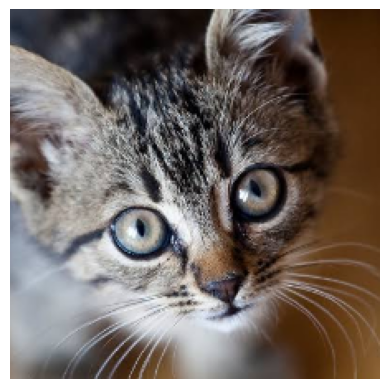

In [93]:
import cv2
def center_crop_to_square(img):
    """
    이미지를 최대 정사각형 크기로 center crop.
    """
    h, w, _ = img.shape  # 원본 이미지 크기
    side_length = min(h, w)  # 정사각형의 한 변 길이
    center_x, center_y = w // 2, h // 2  # 중심 좌표

    # Crop 영역 계산
    x1 = max(center_x - side_length // 2, 0)
    y1 = max(center_y - side_length // 2, 0)
    x2 = x1 + side_length
    y2 = y1 + side_length
    return img[y1:y2, x1:x2]
cat = cv2.imread('cat.jpeg', cv2.IMREAD_COLOR)
cat = center_crop_to_square(cat)
cat = cv2.resize(cat, (224, 224))
from matplotlib import pyplot as plt
if cat is None:
    print("이미지를 읽을 수 없습니다. 경로를 확인하세요.")
else:
    img_rgb = cv2.cvtColor(cat, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

In [94]:
model(torch.tensor(cat/255.0, dtype=torch.float).permute(2, 0, 1).unsqueeze(0))[0].argmax()

tensor(281)

In [95]:
file_path = "pre_weights/batch_20241124_223542.bin"
with open(file_path, 'rb') as f:
    data = np.fromfile(f, dtype=np.float32).reshape(4, 196, 768)
inputs = torch.tensor(data).reshape(4, 14, 14, 3, 16, 16).permute(0, 3, 1, 4, 2, 5).reshape(4, 3, 224, 224)
# inputs = transforms.Normalize((0,0,0),(1,1,1))(inputs)
out = model(inputs)
out[:, 895:895+8], out[0].argmax()
# np_input = inputs.permute(0, 2, 3, 1).numpy()
# plt.imshow(cv2.cvtColor(np_input[0], cv2.COLOR_BGR2RGB))
# np_input[0][0][0],cv2.cvtColor(np_input[0], cv2.COLOR_BGR2RGB)[0][0]

(tensor([[ 3.1379e-01, -4.8609e-02, -1.0948e-01,  8.8215e+00,  3.7668e+00,
           9.3379e-02, -8.3111e-03, -2.1838e-01],
         [ 1.5814e-01, -5.1003e-02, -1.9169e-01,  8.8556e+00,  3.7512e+00,
           6.1902e-02,  5.9275e-02,  3.3882e-02],
         [ 3.0628e-01, -2.9909e-02, -1.1328e-01,  8.6532e+00,  3.6587e+00,
           2.5635e-01,  1.2954e-01,  1.2230e-02],
         [ 3.6171e-01, -6.1784e-02, -4.7301e-02,  8.7059e+00,  3.8768e+00,
           3.2925e-01,  3.5191e-02,  1.4192e-02]], grad_fn=<SliceBackward0>),
 tensor(898))

In [76]:
torch.manual_seed(10)
X = torch.randn(4, 3, 224, 224).reshape(4, 3, 14, 16, 14, 16).permute(0, 2, 4, 1, 3, 5).reshape(4, 196, 768)

In [77]:
torch.manual_seed(10)
# X = torch.randn(4, 3, 224, 224).permute(0, 2, 3, 1).reshape(4, 14, 16, 14, 16, 3).permute(0, 1, 3, 5, 2, 4).reshape(4, 196, 768)
X = torch.randn(4, 224, 224, 3).reshape(4, 14, 16, 14, 16, 3).permute(0, 1, 3, 5, 2, 4).reshape(4, 196, 768)

X

tensor([[[-8.1733e-01, -1.2970e+00, -5.1330e-01,  ...,  6.3402e-01,
          -8.5365e-01, -1.2612e+00],
         [-4.8110e-01,  2.7470e+00, -9.1798e-01,  ...,  1.7499e-01,
           1.5737e-01, -1.6411e+00],
         [ 2.6069e-01, -1.4865e-01, -2.7535e-01,  ...,  9.9325e-01,
           1.1182e-03,  2.1105e+00],
         ...,
         [-1.4912e+00,  8.5537e-01,  8.9112e-01,  ...,  1.3747e+00,
          -1.0284e-01, -9.4909e-01],
         [ 6.6846e-01, -9.0727e-01, -2.2956e-01,  ..., -1.8203e+00,
           9.5288e-01, -2.4488e-01],
         [ 5.5344e-01, -2.2165e-01, -1.1989e+00,  ..., -5.2533e-01,
          -1.8627e-01,  9.4053e-01]],

        [[ 6.4443e-02, -2.0222e-01,  9.2096e-01,  ..., -9.4626e-01,
          -1.8723e+00,  1.4939e+00],
         [-6.2627e-01,  3.9364e-01, -2.9583e-01,  ..., -7.9189e-01,
          -6.7734e-01,  1.7716e+00],
         [ 2.5688e-01,  1.0149e+00, -9.2163e-01,  ..., -2.3724e-01,
           3.3885e-01,  7.5314e-01],
         ...,
         [-2.3617e-01,  1

In [3]:
torch.manual_seed(10)
inputs = torch.randn(4, 196, 768).reshape(4, 14, 14, 3, 16, 16).permute(0, 3, 1, 4, 2, 5).reshape(4, 3, 224, 224)

In [4]:

input = torch.tensor(data, dtype=torch.float16).reshape(4, 14, 14, 3, 16, 16).permute(0, 3, 1, 4, 2, 5).reshape(4, 3, 224, 224)
# inputs = torch.tensor(data, dtype=torch.float32).reshape(4, 14, 14, 3, 16, 16).permute(0, 3, 1, 4, 2, 5).reshape(4, 3, 224, 224)
type(inputs)

torch.Tensor

In [5]:
for i in range(12):
    list(model.blocks.children())[i].attn.flash_attn = False

In [6]:
(dict(model.patch_embed.named_children())['proj'].weight).dtype

torch.float32

In [7]:
device = torch.device('cuda')
start = time.time()
inputs = torch.tensor(input.detach(), dtype=torch.float32)
# model = model.full()
modeld = model.to(device)


for i in range(100):
    
    input_d = inputs.to(device)
    output = modeld(input_d)
    output = output.to('cpu')
    print(f'output : {output}')
end = time.time()-start
print(f'time : {end}sec')


/tmp/ipykernel_11250/21709948.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(input.detach(), dtype=torch.float32)


output : tensor([[-0.6506,  0.5699,  0.9909,  ..., -0.6971, -0.0040,  0.3011],
        [-0.5880,  0.3263,  0.6494,  ..., -0.4701,  0.1757,  0.2660],
        [-0.4764,  0.2062,  0.5736,  ..., -0.4387,  0.2734,  0.0986],
        [-0.6797,  0.2667,  0.9374,  ..., -0.5675, -0.0464,  0.2711]],
       grad_fn=<ToCopyBackward0>)
output : tensor([[-0.6506,  0.5699,  0.9909,  ..., -0.6971, -0.0040,  0.3011],
        [-0.5880,  0.3263,  0.6494,  ..., -0.4701,  0.1757,  0.2660],
        [-0.4764,  0.2062,  0.5736,  ..., -0.4387,  0.2734,  0.0986],
        [-0.6797,  0.2667,  0.9374,  ..., -0.5675, -0.0464,  0.2711]],
       grad_fn=<ToCopyBackward0>)
output : tensor([[-0.6506,  0.5699,  0.9909,  ..., -0.6971, -0.0040,  0.3011],
        [-0.5880,  0.3263,  0.6494,  ..., -0.4701,  0.1757,  0.2660],
        [-0.4764,  0.2062,  0.5736,  ..., -0.4387,  0.2734,  0.0986],
        [-0.6797,  0.2667,  0.9374,  ..., -0.5675, -0.0464,  0.2711]],
       grad_fn=<ToCopyBackward0>)
output : tensor([[-0.6506,  

In [8]:
output[:,18:25]

tensor([[3.5802, 1.8356, 1.5026, 5.7263, 4.8259, 4.7571, 1.8068],
        [3.0856, 1.6712, 1.2817, 5.1314, 3.9570, 4.0317, 1.9194],
        [3.5102, 1.8066, 1.5194, 5.2363, 4.4751, 4.3398, 2.1461],
        [3.3421, 1.6897, 1.4245, 5.4187, 4.6329, 4.4575, 1.9495]],
       grad_fn=<SliceBackward0>)

In [9]:
output[:,18:25]

tensor([[3.5802, 1.8356, 1.5026, 5.7263, 4.8259, 4.7571, 1.8068],
        [3.0856, 1.6712, 1.2817, 5.1314, 3.9570, 4.0317, 1.9194],
        [3.5102, 1.8066, 1.5194, 5.2363, 4.4751, 4.3398, 2.1461],
        [3.3421, 1.6897, 1.4245, 5.4187, 4.6329, 4.4575, 1.9495]],
       grad_fn=<SliceBackward0>)

In [20]:
ls = [4, 196, 12, 3, 64]
def mult(ls):
    res = 1
    for i in ls:
        res *= i
    return res
torch.arange(mult(ls)).reshape(ls).permute(3, 0, 2, 1, 4)[1,0,1,0,:]

tensor([320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333,
        334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347,
        348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361,
        362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375,
        376, 377, 378, 379, 380, 381, 382, 383])

In [33]:
Q = torch.arange(mult(ls)).reshape(ls).permute(3, 0, 2, 1, 4)[0].float()
K = torch.arange(mult(ls)).reshape(ls).permute(3, 0, 2, 1, 4)[1].float()
nn.LayerNorm((196,),)(torch.matmul(Q, K.permute(0, 1, 3, 2)))

tensor([[[[-1.7232, -1.7056, -1.6879,  ...,  1.6879,  1.7056,  1.7232],
          [-1.7232, -1.7056, -1.6879,  ...,  1.6879,  1.7056,  1.7232],
          [-1.7232, -1.7056, -1.6879,  ...,  1.6879,  1.7056,  1.7232],
          ...,
          [-1.7232, -1.7056, -1.6879,  ...,  1.6879,  1.7056,  1.7232],
          [-1.7232, -1.7056, -1.6879,  ...,  1.6879,  1.7056,  1.7232],
          [-1.7232, -1.7056, -1.6879,  ...,  1.6879,  1.7056,  1.7232]],

         [[-1.7232, -1.7056, -1.6879,  ...,  1.6879,  1.7056,  1.7232],
          [-1.7232, -1.7056, -1.6879,  ...,  1.6879,  1.7056,  1.7232],
          [-1.7232, -1.7056, -1.6879,  ...,  1.6879,  1.7056,  1.7232],
          ...,
          [-1.7232, -1.7056, -1.6879,  ...,  1.6879,  1.7056,  1.7232],
          [-1.7232, -1.7056, -1.6879,  ...,  1.6879,  1.7056,  1.7232],
          [-1.7232, -1.7056, -1.6879,  ...,  1.6879,  1.7056,  1.7232]],

         [[-1.7232, -1.7056, -1.6879,  ...,  1.6879,  1.7056,  1.7232],
          [-1.7232, -1.7056, -